# ENSO (Niño3.4) in EERIE IFS-FESOM2-SR — HIST + SSP2-4.5, 3-member ensemble

Niño3.4 index and ENSO diagnostics for **IFS-FESOM2-SR**.

**Per-member time coverage (important):**
- **ens1**: 1950–2097  (HIST 1950–2014  +  SSP245 2015–2097)
- **ens2**: 1975–2030  (HIST 1975–2014  +  SSP245 2015–2030)
- **ens3**: 1975–2030  (HIST 1975–2014  +  SSP245 2015–2030)

Each member is kept on its **own native time axis** throughout. Diagnostics that
combine members (ensemble mean, spread) are restricted to the **common overlap
1975–2030**. Single-member diagnostics (running std, histograms, events,
seasonality, spectrum) use each member's full period.

**Pipeline per member:** cos-lat area average over the Niño3.4 box → linear
detrend (removes forced warming) → remove monthly climatology → 3-month running mean.

**Caveats**
- Paths point at DKRZ `/work/bm1344/...`; run on the HPC.
- FESOM folder-numbering offset: notebook `ens2` ↔ `…ENS1…` folder, `ens3` ↔ `…ENS2…` folder. Flip `FESOM_MEMBERS` if reversed.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
MEMBER_COLORS = {"ens1": "#1b9e77", "ens2": "#d95f02", "ens3": "#7570b3"}


In [2]:
# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
OCEAN_VAR = "avg_tos"          # FESOM surface temperature (Kelvin in raw files)

# Niño3.4 box: 5S-5N, 170W-120W  (= 190-240 in 0-360 longitude)
NINO34 = dict(latS=-5, latN=5, lonL=190, lonR=240)

# HIST/SSP boundary is the same for every member: HIST <=2014, SSP >=2015.
# What differs is each member's overall coverage.
FESOM_MEMBERS = {
    "ens1": dict(
        hist="/work/bm1344/a270228/Phase1-HIST-FESOM/monthly/2d/avg_tos",
        ssp ="/work/bm1344/a270228/Phase1-SSP245-FESOM/monthly/2d/avg_tos",
        hist_slice=slice("1950", "2014"),
        ssp_slice =slice("2015", "2097"),
    ),
    "ens2": dict(
        hist="/work/bm1344/a270228/Phase2-HIST-ENS1-FESOM/monthly/2d/avg_tos",
        ssp ="/work/bm1344/a270228/Phase2-SSP245-ENS1-FESOM/monthly/2d/avg_tos",
        hist_slice=slice("1975", "2014"),
        ssp_slice =slice("2015", "2030"),
    ),
    "ens3": dict(
        hist="/work/bm1344/a270228/Phase2-HIST-ENS2-FESOM/monthly/2d/avg_tos",
        ssp ="/work/bm1344/a270228/Phase2-SSP245-ENS2-FESOM/monthly/2d/avg_tos",
        hist_slice=slice("1975", "2014"),
        ssp_slice =slice("2015", "2030"),
    ),
}

# Common overlap window (all three members exist here)
COMMON = slice("1975", "2030")


In [3]:
# ----------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------
def open_fesom(folder, var=OCEAN_VAR):
    return xr.open_mfdataset(f"{folder}/{var}_*.nc")


def wgt_areaave(indat, latS, latN, lonW, lonE):
    """cos(lat)-weighted area average over a lat/lon box."""
    lat = indat.lat
    lon = indat.lon
    if ((lonW < 0) or (lonE < 0)) and (lon.values.min() > -1):
        anm = indat.assign_coords(lon=((lon + 180) % 360 - 180))
    else:
        anm = indat
    iplat = lat.where((lat >= latS) & (lat <= latN), drop=True)
    iplon = lon.where((lon >= lonW) & (lon <= lonE), drop=True)
    wgt = np.cos(np.deg2rad(lat))
    return anm.sel(lat=iplat, lon=iplon).weighted(wgt).mean(("lon", "lat"), skipna=True)


def load_surface_tos(folder, time_slice):
    """Open a FESOM folder, take surface level, K->C, subset time."""
    ds = open_fesom(folder)
    da = ds[OCEAN_VAR]
    if da.ndim == 4:
        da = da[:, 0, :, :]
    da = da - 273.15
    return da.sel(time=time_slice)


def nino34_index(cfg, box=NINO34, smooth_months=3):
    """Full Niño3.4 pipeline for one member, using that member's own slices.
       Returns (index_smoothed, anomalies_unsmoothed) on the member's native axis."""
    ts_h = load_surface_tos(cfg["hist"], cfg["hist_slice"])
    ts_s = load_surface_tos(cfg["ssp"],  cfg["ssp_slice"])

    nino_h = wgt_areaave(ts_h, box["latS"], box["latN"], box["lonL"], box["lonR"])
    nino_s = wgt_areaave(ts_s, box["latS"], box["latN"], box["lonL"], box["lonR"])
    nino = xr.concat([nino_h, nino_s], dim="time").sortby("time")

    coef = nino.polyfit(dim="time", deg=1)
    fit  = xr.polyval(nino["time"], coef.polyfit_coefficients)
    nino_dt = nino - fit

    gb = nino_dt.groupby("time.month")
    anom = gb - gb.mean(dim="time")

    idx = anom.rolling(time=smooth_months, center=True).mean()
    return idx.rename("nino34"), anom.rename("nino34_anom")


In [4]:
# ----------------------------------------------------------------------
# Build the Niño3.4 index for every member (native time axes)
# ----------------------------------------------------------------------
indices = {}   # smoothed index per member
anoms   = {}   # unsmoothed anomalies per member

for m, cfg in FESOM_MEMBERS.items():
    print(f"Processing {m} ...")
    idx, anom = nino34_index(cfg)
    indices[m] = idx.load()
    anoms[m]   = anom.load()
    print(f"  {m}: {str(idx.time.values[0])[:7]} -> {str(idx.time.values[-1])[:7]}  "
          f"({idx.time.size} months)")

members = list(indices)


Processing ens1 ...


/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/xarray/core/indexing.py:1440: PerformanceWarning: Slicing with an out-of-order index is generating 148 times more chunks
  return self.array[key]


  ens1: 1950-01 -> 2097-12  (1776 months)
Processing ens2 ...


/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/xarray/core/indexing.py:1440: PerformanceWarning: Slicing with an out-of-order index is generating 56 times more chunks
  return self.array[key]


  ens2: 1975-01 -> 2030-12  (672 months)
Processing ens3 ...


/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/xarray/core/indexing.py:1440: PerformanceWarning: Slicing with an out-of-order index is generating 56 times more chunks
  return self.array[key]


  ens3: 1975-01 -> 2030-12  (672 months)


## 1. Niño3.4 index per member (each on its own period)

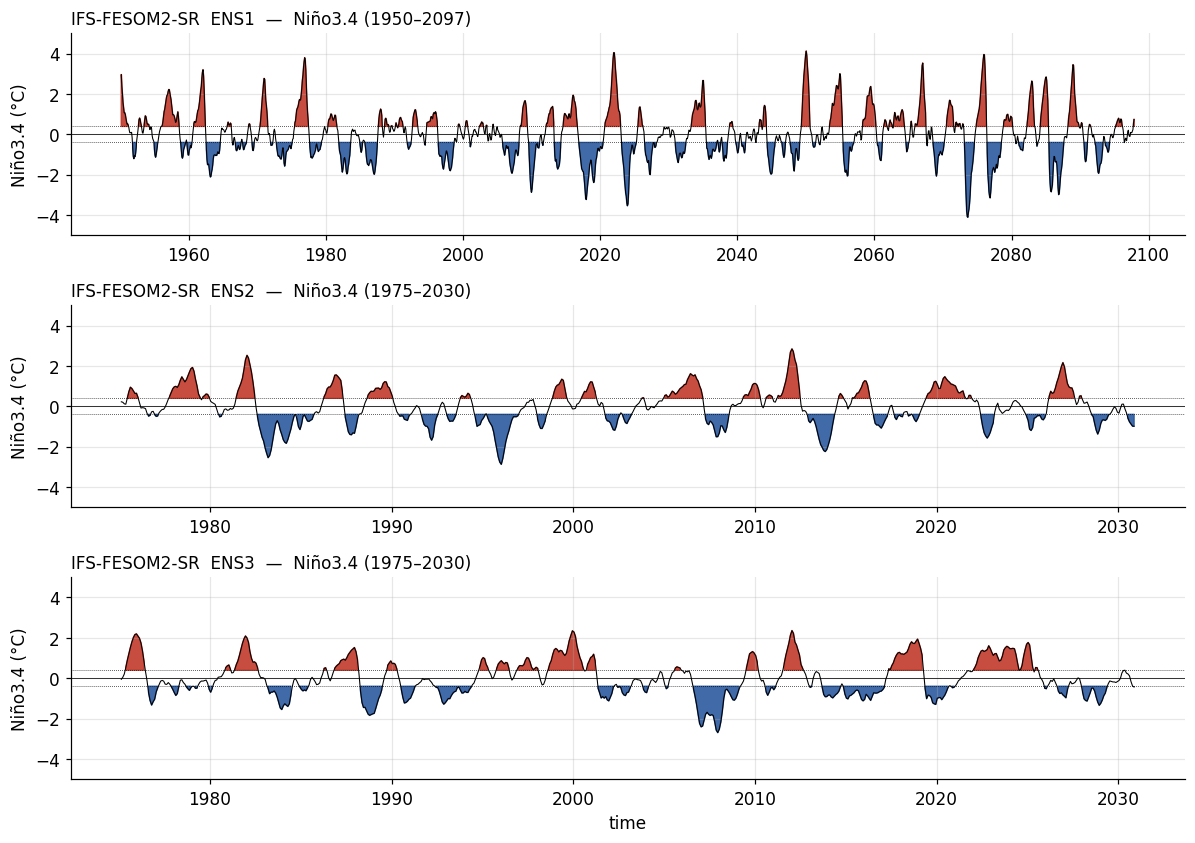

In [5]:
def shaded_nino(ax, series, title, thr=0.4):
    t = series.time.data
    ax.fill_between(t, series.where(series >= thr).data, thr, color="#c0392b", alpha=0.9)
    ax.fill_between(t, series.where(series <= -thr).data, -thr, color="#2c5aa0", alpha=0.9)
    ax.plot(t, series.data, color="black", lw=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(thr,  color="black", lw=0.5, ls="dotted")
    ax.axhline(-thr, color="black", lw=0.5, ls="dotted")
    ax.set_ylim(-5, 5)
    ax.set_ylabel("Niño3.4 (°C)")
    ax.set_title(title, fontsize=11, loc="left")

fig, axes = plt.subplots(len(members), 1, figsize=(11, 2.6 * len(members)), sharex=False)
if len(members) == 1:
    axes = [axes]
for ax, m in zip(axes, members):
    cov = f"{str(indices[m].time.values[0])[:4]}–{str(indices[m].time.values[-1])[:4]}"
    shaded_nino(ax, indices[m], f"IFS-FESOM2-SR  {m.upper()}  —  Niño3.4 ({cov})")
axes[-1].set_xlabel("time")
fig.tight_layout()
fig.savefig("nino34_per_member.png", bbox_inches="tight")
plt.show()


## 1a. Shaded index — shared 1950–2097 axis, members on their own data

Three stacked panels sharing the **same x-axis (1950–2097)**. ens1 fills the whole
span; ens2/ens3 draw only where they have data (1975–2030) and are left blank
elsewhere, so you can see exactly where in ens1's timeline the short members sit.

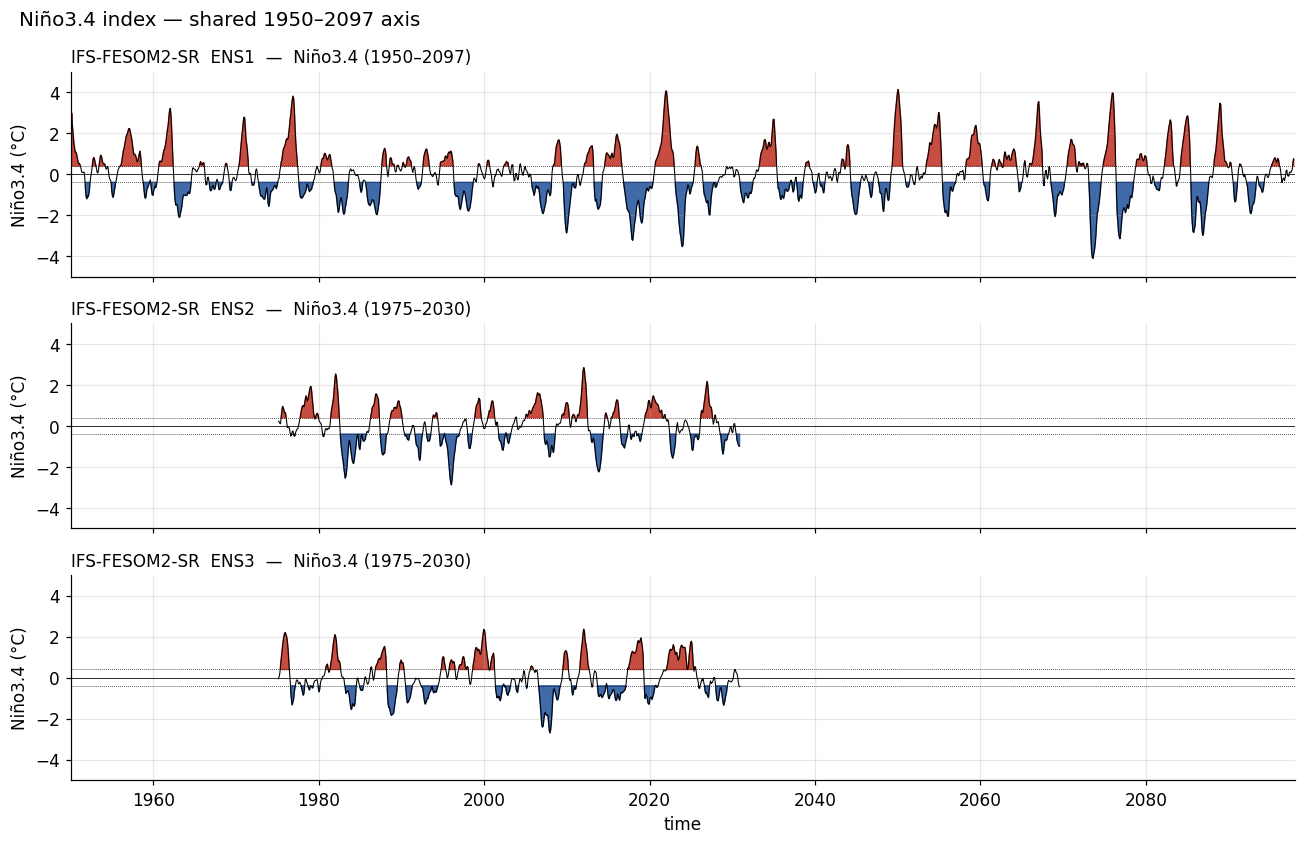

In [6]:
FULL_XLIM = (np.datetime64("1950-01-01"), np.datetime64("2098-01-01"))

fig, axes = plt.subplots(len(members), 1, figsize=(12, 2.6 * len(members)),
                         sharex=True)
if len(members) == 1:
    axes = [axes]
for ax, m in zip(axes, members):
    cov = f"{str(indices[m].time.values[0])[:4]}\u2013{str(indices[m].time.values[-1])[:4]}"
    shaded_nino(ax, indices[m], f"IFS-FESOM2-SR  {m.upper()}  \u2014  Ni\u00f1o3.4 ({cov})")
# convert cftime/datetime axis limits robustly: use the ens1 (full) axis extent
try:
    axes[0].set_xlim(FULL_XLIM)
except Exception:
    # fall back to ens1's own time range if calendar is cftime (non-numpy)
    t = indices["ens1"].time.values
    axes[0].set_xlim(t[0], t[-1])
axes[-1].set_xlabel("time")
fig.suptitle("Ni\u00f1o3.4 index \u2014 shared 1950\u20132097 axis", x=0.02, ha="left", fontsize=13)
fig.tight_layout()
fig.savefig("nino34_per_member_sharedaxis.png", bbox_inches="tight")
plt.show()

## 1b. Shaded index — common period 1975–2030, all three members

The same three-panel shaded view but with every panel **zoomed to 1975–2030**,
for a tight side-by-side of the members over their common window.

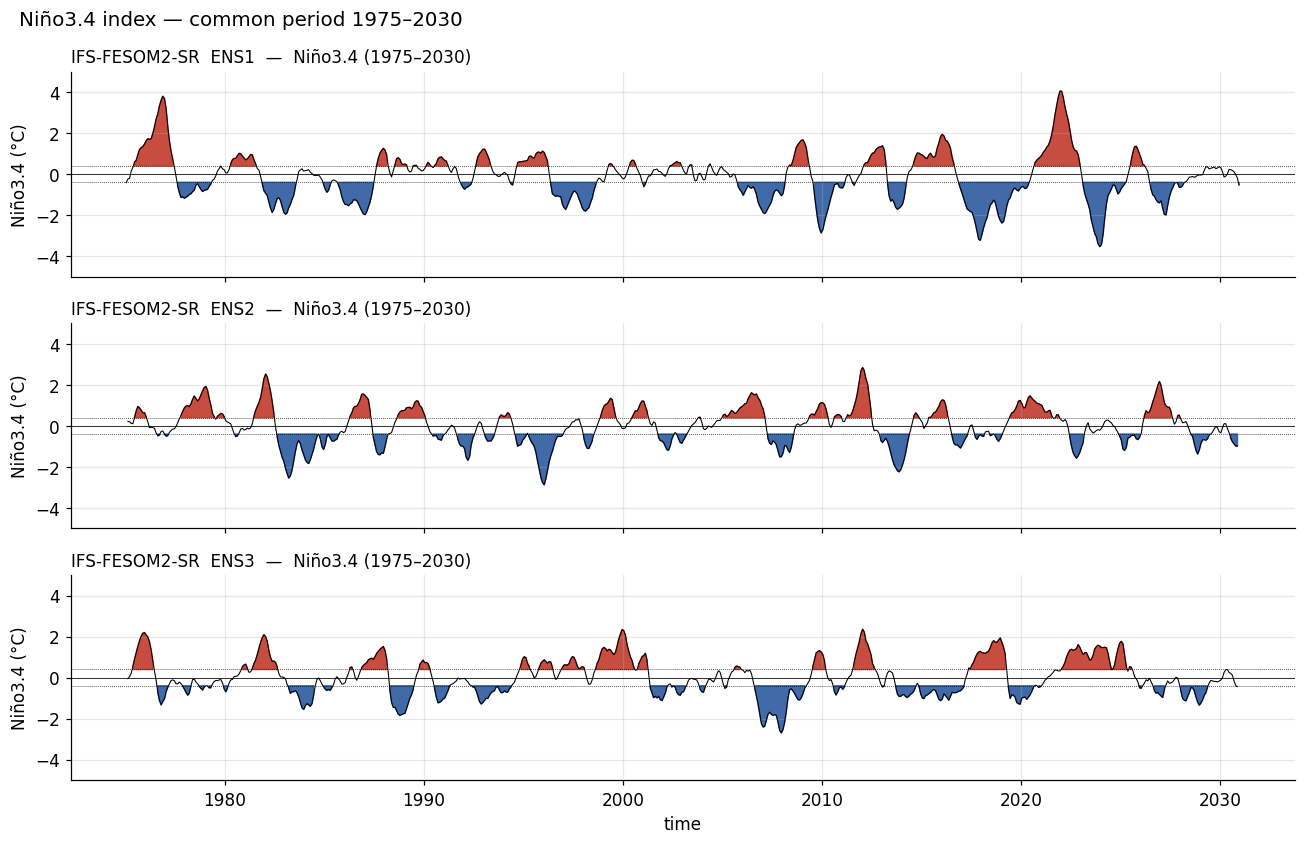

In [7]:
fig, axes = plt.subplots(len(members), 1, figsize=(12, 2.6 * len(members)),
                         sharex=True)
if len(members) == 1:
    axes = [axes]
for ax, m in zip(axes, members):
    s = indices[m].sel(time=COMMON)
    shaded_nino(ax, s, f"IFS-FESOM2-SR  {m.upper()}  \u2014  Ni\u00f1o3.4 (1975\u20132030)")
axes[-1].set_xlabel("time")
fig.suptitle("Ni\u00f1o3.4 index \u2014 common period 1975\u20132030", x=0.02, ha="left", fontsize=13)
fig.tight_layout()
fig.savefig("nino34_per_member_common1975-2030.png", bbox_inches="tight")
plt.show()

## 1c. Common-baseline index for inter-member comparison

The indices above use each member's **own** full record for the detrend and
monthly climatology — correct for single-member diagnostics. For *comparison*
plots (1a, 1b, section 6) that's inconsistent, because ens1's baseline spans
1950–2097 while ens2/ens3 span 1975–2030.

Here we build a second index, `indices_cb`, where the linear detrend **and** the
monthly climatology are both computed over the **common 1975–2030 window** for
every member, then applied across each member's full record. This makes the
comparison strictly apples-to-apples (same baseline seasonal cycle, same detrend
window for all three). Single-member sections keep using `indices`.

In [8]:
def nino34_index_common_baseline(cfg, common=COMMON, box=NINO34, smooth_months=3):
    """Like nino34_index, but detrend slope and monthly climatology are both
    estimated over `common` (1975-2030) and applied to the member's full record.
    Returns (index_smoothed, anomalies_unsmoothed) on the member's native axis."""
    ts_h = load_surface_tos(cfg["hist"], cfg["hist_slice"])
    ts_s = load_surface_tos(cfg["ssp"],  cfg["ssp_slice"])
    nino_h = wgt_areaave(ts_h, box["latS"], box["latN"], box["lonL"], box["lonR"])
    nino_s = wgt_areaave(ts_s, box["latS"], box["latN"], box["lonL"], box["lonR"])
    nino = xr.concat([nino_h, nino_s], dim="time").sortby("time")

    # detrend: fit the line on the COMMON window, evaluate over the full axis
    coef = nino.sel(time=common).polyfit(dim="time", deg=1)
    fit  = xr.polyval(nino["time"], coef.polyfit_coefficients)
    nino_dt = nino - fit

    # climatology: monthly means over the COMMON window only
    clim = nino_dt.sel(time=common).groupby("time.month").mean("time")
    anom = nino_dt.groupby("time.month") - clim

    idx = anom.rolling(time=smooth_months, center=True).mean()
    return idx.rename("nino34_cb"), anom.rename("nino34_cb_anom")

indices_cb = {}
anoms_cb   = {}
for m, cfg in FESOM_MEMBERS.items():
    icb, acb = nino34_index_common_baseline(cfg)
    indices_cb[m] = icb.load()
    anoms_cb[m]   = acb.load()
print("Common-baseline indices built (detrend + climatology over 1975-2030).")

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/xarray/core/indexing.py:1440: PerformanceWarning: Slicing with an out-of-order index is generating 148 times more chunks
  return self.array[key]
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/xarray/core/indexing.py:1440: PerformanceWarning: Slicing with an out-of-order index is generating 56 times more chunks
  return self.array[key]
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/xarray/core/indexing.py:1440: PerformanceWarning: Slicing with an out-of-order index is generating 56 times more chunks
  return self.array[key]


Common-baseline indices built (detrend + climatology over 1975-2030).


## 2. Ensemble mean and spread — common period 1975–2030 only

All three members exist here, so the mean and ±1 sd spread are computed on a
shared monthly axis restricted to **1975–2030**. Outside this window the ensemble
is not defined (ens2/ens3 don't cover it), so we deliberately do not plot it.

common axis: 1975-01 -> 2030-12 669 months


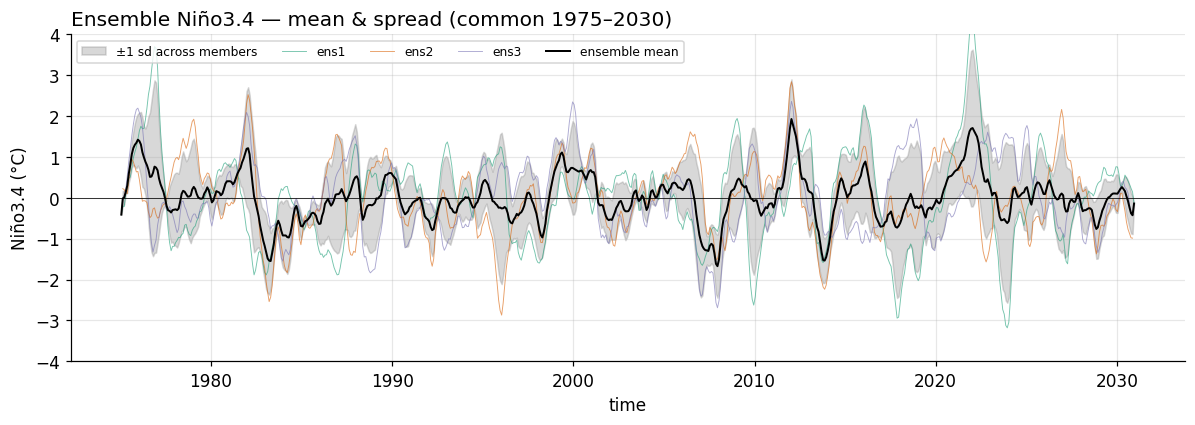

In [9]:
# Align the three members on the common window before combining
idx_common = xr.concat(
    [indices_cb[m].sel(time=COMMON) for m in members],
    dim=pd.Index(members, name="member"),
    join="inner",          # intersection of time axes -> no NaN padding
)
print("common axis:", str(idx_common.time.values[0])[:7],
      "->", str(idx_common.time.values[-1])[:7], idx_common.time.size, "months")

ens_mean = idx_common.mean("member")
ens_std  = idx_common.std("member")

fig, ax = plt.subplots(figsize=(11, 4))
t = ens_mean.time.data
ax.fill_between(t, (ens_mean - ens_std).data, (ens_mean + ens_std).data,
                color="grey", alpha=0.3, label="±1 sd across members")
for m in members:
    s = indices_cb[m].sel(time=COMMON)
    ax.plot(s.time.data, s.data, color=MEMBER_COLORS[m], lw=0.6, alpha=0.6, label=m)
ax.plot(t, ens_mean.data, color="black", lw=1.3, label="ensemble mean")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylim(-4, 4)
ax.set_ylabel("Niño3.4 (°C)")
ax.set_xlabel("time")
ax.set_title("Ensemble Niño3.4 — mean & spread (common 1975–2030)", loc="left")
ax.legend(ncol=5, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("nino34_ensemble_common.png", bbox_inches="tight")
plt.show()


## 3. Amplitude evolution — running standard deviation (full period)

Each member drawn over its own coverage. The window is 21 yr for ens1; for the
shorter ens2/ens3 (56 yr total) a 21-yr window leaves few estimates, so a
**reduced 11-yr window** is used for those. Both windows are reported.

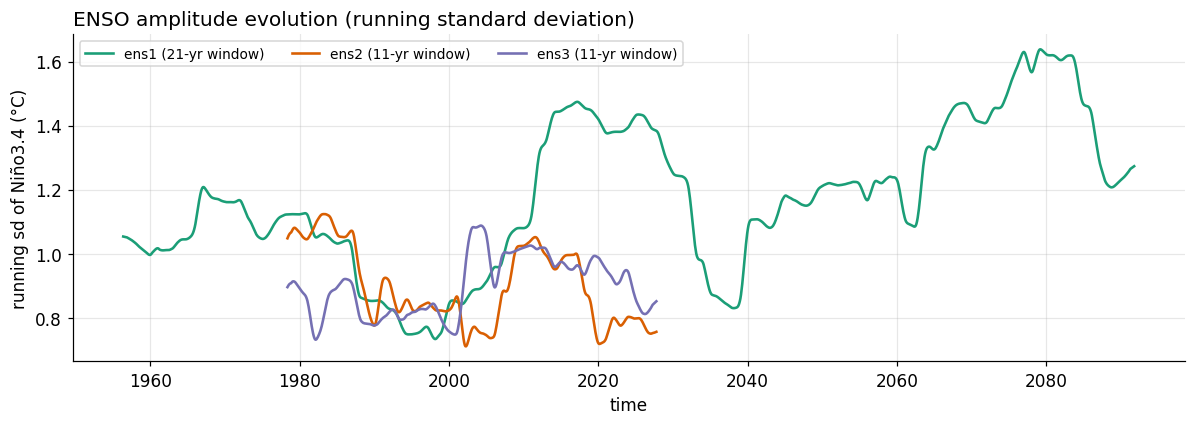

In [10]:
def running_std(series, win_years):
    w = win_years * 12
    rs = series.rolling(time=w, center=True, min_periods=int(w * 0.8)).std()
    return rs.rolling(time=12, center=True, min_periods=6).mean()

# member -> window length (years)
WIN_BY_MEMBER = {"ens1": 21, "ens2": 11, "ens3": 11}

fig, ax = plt.subplots(figsize=(11, 4))
for m in members:
    w = WIN_BY_MEMBER.get(m, 11)
    rs = running_std(indices[m], w)
    ax.plot(rs.time.data, rs.data, color=MEMBER_COLORS[m], lw=1.7,
            label=f"{m} ({w}-yr window)")
ax.set_ylabel("running sd of Niño3.4 (°C)")
ax.set_xlabel("time")
ax.set_title("ENSO amplitude evolution (running standard deviation)", loc="left")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig("nino34_running_std.png", bbox_inches="tight")
plt.show()


## 4. Early vs late distribution & skewness

A full early-vs-late contrast only makes sense for **ens1** (1950–2097). For
ens2/ens3 (1975–2030) there is no late-century period, so for those we instead
split their own record in half (1975–2002 vs 2003–2030) — flagged on each panel.

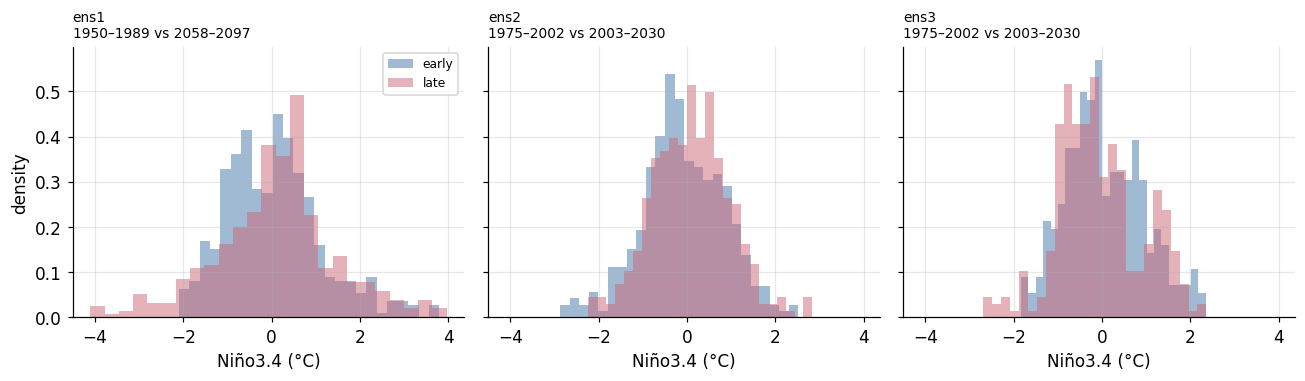

,window,sd_early,sd_late,skew_early,skew_late,sd_change_%
member,,,,,,
ens1,1950–1989 vs 2058–2097,1.08,1.358,0.700,-0.125,25.698
ens2,1975–2002 vs 2003–2030,0.94,0.868,-0.128,0.123,-7.676
ens3,1975–2002 vs 2003–2030,0.88,0.952,0.326,0.132,8.165


In [11]:
from scipy.stats import skew

def split_windows(series):
    """Return (early_slice, late_slice, label) appropriate to coverage."""
    y0 = int(str(series.time.values[0])[:4])
    y1 = int(str(series.time.values[-1])[:4])
    if (y1 - y0) > 90:                      # long member (ens1)
        return slice("1950", "1989"), slice("2058", "2097"), "1950–1989 vs 2058–2097"
    mid = (y0 + y1) // 2
    return (slice(str(y0), str(mid)), slice(str(mid + 1), str(y1)),
            f"{y0}–{mid} vs {mid+1}–{y1}")

rows = []
fig, axes = plt.subplots(1, len(members), figsize=(4 * len(members), 3.6),
                         sharex=True, sharey=True)
if len(members) == 1:
    axes = [axes]
for ax, m in zip(axes, members):
    e_sl, l_sl, lab = split_windows(indices[m])
    e = indices[m].sel(time=e_sl).dropna("time").data
    l = indices[m].sel(time=l_sl).dropna("time").data
    ax.hist(e, bins=25, density=True, alpha=0.5, color="#4477aa", label="early")
    ax.hist(l, bins=25, density=True, alpha=0.5, color="#cc6677", label="late")
    ax.set_title(f"{m}\n{lab}", loc="left", fontsize=9)
    ax.set_xlabel("Niño3.4 (°C)")
    rows.append(dict(member=m, window=lab,
                     sd_early=np.nanstd(e), sd_late=np.nanstd(l),
                     skew_early=skew(e),    skew_late=skew(l)))
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig("nino34_early_vs_late.png", bbox_inches="tight")
plt.show()

stats_df = pd.DataFrame(rows).set_index("member")
stats_df["sd_change_%"] = 100 * (stats_df.sd_late - stats_df.sd_early) / stats_df.sd_early
stats_df.round(3)


## 5. Event statistics — full period per member

Event = run of ≥5 consecutive months beyond ±0.5 °C. Counts are also given as a
**rate per decade** so the short and long members can be compared fairly.

In [12]:
def find_events(series, thr=0.5, min_len=5, warm=True):
    s = series.dropna("time"); vals = s.data; t = s.time.values
    mask = vals >= thr if warm else vals <= -thr
    ev, i, n = [], 0, len(vals)
    while i < n:
        if mask[i]:
            j = i
            while j < n and mask[j]:
                j += 1
            if (j - i) >= min_len:
                seg = vals[i:j]
                peak = seg.max() if warm else seg.min()
                ev.append((t[i], t[j - 1], float(peak), j - i))
            i = j
        else:
            i += 1
    return ev

rows = []
for m in members:
    s = indices[m]
    n_years = (int(str(s.time.values[-1])[:4]) - int(str(s.time.values[0])[:4]) + 1)
    for warm, name in [(True, "El Niño"), (False, "La Niña")]:
        ev = find_events(s, warm=warm)
        durs  = [e[3] for e in ev]
        peaks = [e[2] for e in ev]
        rows.append(dict(
            member=m, phase=name, n_events=len(ev),
            per_decade=round(10 * len(ev) / n_years, 2),
            mean_dur_mo=round(np.mean(durs), 1) if durs else np.nan,
            mean_peak=round(np.mean(peaks), 2) if peaks else np.nan,
            max_peak=round((max(peaks) if warm else min(peaks)), 2) if peaks else np.nan,
        ))
events_df = pd.DataFrame(rows)
events_df


,member,phase,n_events,per_decade,mean_dur_mo,mean_peak,max_peak
0,ens1,El Niño,32,2.16,15.0,2.12,4.13
1,ens1,La Niña,39,2.64,14.5,-1.68,-4.10
2,ens2,El Niño,13,2.32,13.8,1.63,2.84
3,ens2,La Niña,17,3.04,10.1,-1.42,-2.87
4,ens3,El Niño,14,2.50,12.8,1.58,2.36
5,ens3,La Niña,15,2.68,12.3,-1.30,-2.69


## 6. Common-period comparison (1975–2030)

The honest side-by-side: all diagnostics below are computed on the **same
1975–2030 window** for every member, so differences reflect the runs, not their
differing coverage. Four panels: index overlay, running sd, seasonal
phase-locking, and spectra.

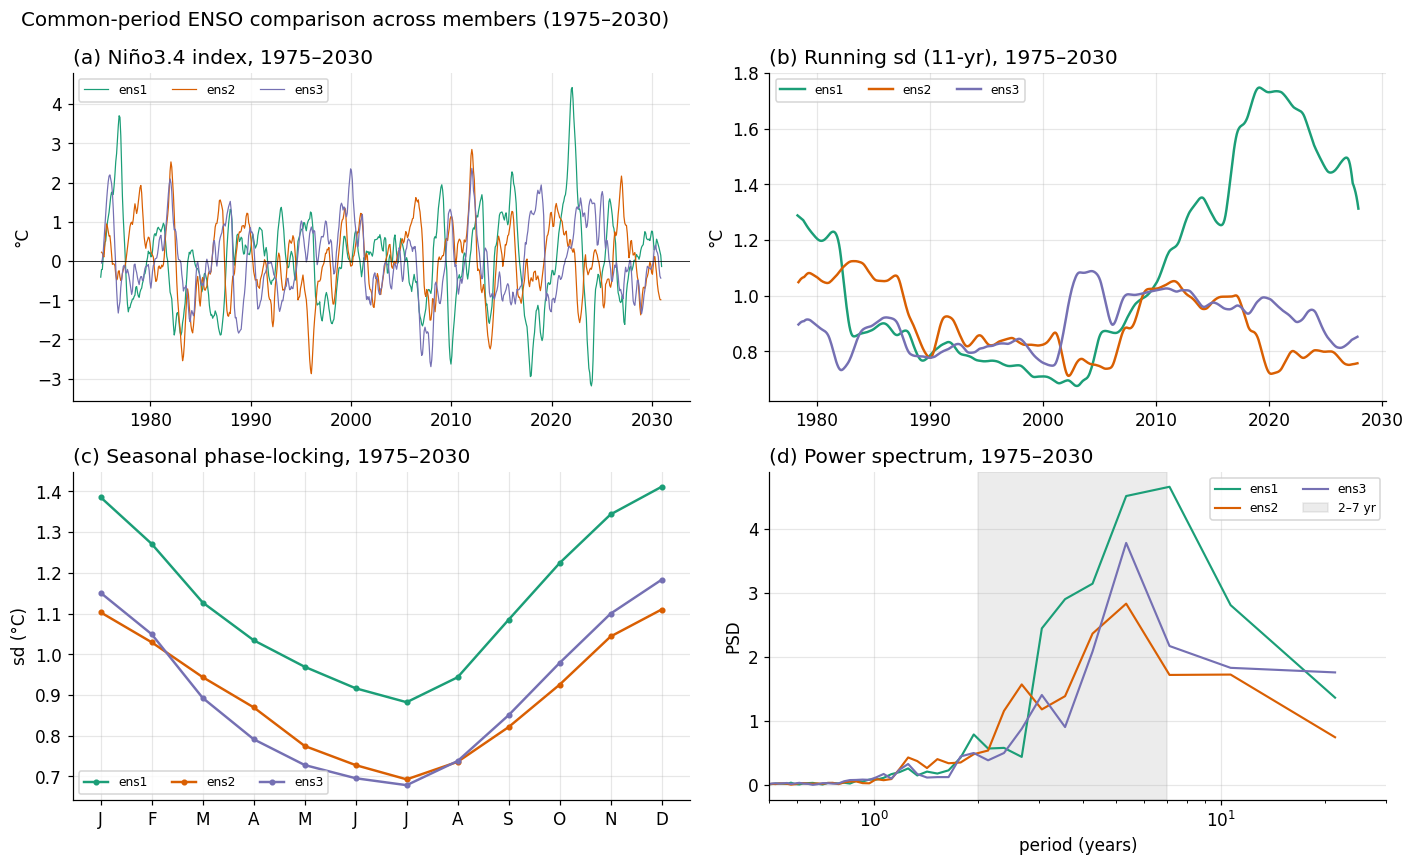

In [13]:
from scipy.signal import welch

fig, axs = plt.subplots(2, 2, figsize=(13, 8))

# (a) index overlay
ax = axs[0, 0]
for m in members:
    s = indices_cb[m].sel(time=COMMON)
    ax.plot(s.time.data, s.data, color=MEMBER_COLORS[m], lw=0.8, label=m)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("(a) Niño3.4 index, 1975–2030", loc="left")
ax.set_ylabel("°C"); ax.legend(fontsize=8, ncol=3)

# (b) running sd on common window (11-yr)
ax = axs[0, 1]
for m in members:
    rs = running_std(indices_cb[m].sel(time=COMMON), 11)
    ax.plot(rs.time.data, rs.data, color=MEMBER_COLORS[m], lw=1.6, label=m)
ax.set_title("(b) Running sd (11-yr), 1975–2030", loc="left")
ax.set_ylabel("°C"); ax.legend(fontsize=8, ncol=3)

# (c) seasonal phase-locking on common window
ax = axs[1, 0]
months = np.arange(1, 13)
for m in members:
    sd_month = indices_cb[m].sel(time=COMMON).groupby("time.month").std()
    ax.plot(months, sd_month.sel(month=months).data,
            color=MEMBER_COLORS[m], lw=1.6, marker="o", ms=3, label=m)
ax.set_xticks(months)
ax.set_xticklabels(list("JFMAMJJASOND"))
ax.set_title("(c) Seasonal phase-locking, 1975–2030", loc="left")
ax.set_ylabel("sd (°C)"); ax.legend(fontsize=8, ncol=3)

# (d) spectra on common window (unsmoothed anomalies)
ax = axs[1, 1]
for m in members:
    x = anoms_cb[m].sel(time=COMMON).dropna("time").data
    f, P = welch(x, fs=12.0, nperseg=min(len(x), 256))
    with np.errstate(divide="ignore"):
        period = 1.0 / f
    ax.semilogx(period[1:], P[1:], color=MEMBER_COLORS[m], lw=1.4, label=m)
ax.axvspan(2, 7, color="grey", alpha=0.15, label="2–7 yr")
ax.set_xlim(0.5, 30)
ax.set_title("(d) Power spectrum, 1975–2030", loc="left")
ax.set_xlabel("period (years)"); ax.set_ylabel("PSD"); ax.legend(fontsize=8, ncol=2)

fig.suptitle("Common-period ENSO comparison across members (1975–2030)",
             x=0.02, ha="left", fontsize=13)
fig.tight_layout()
fig.savefig("nino34_common_comparison.png", bbox_inches="tight")
plt.show()
